# 05 — Diffusion Model (DDPM) for Anomaly Detection

This notebook implements a minimal **Denoising Diffusion Probabilistic Model (DDPM)** for anomaly detection on the NASA SMAP/MSL dataset.

## Approach: Partial Noising + Reconstruction

The key insight is that a diffusion model trained on **normal** data learns to reconstruct normal patterns faithfully:

1. **Forward process**: Add Gaussian noise at a fixed intermediate step `t_eval` to partially corrupt the input window.
2. **Reverse process**: Run the learned denoiser from `t_eval` back to `t=0` to reconstruct the original.
3. **Anomaly score**: `MSE(original, reconstructed)` — normal windows reconstruct with low error; anomalous windows yield higher reconstruction error because the model never learned those patterns.

### Why this works
- Normal data: the model has seen similar patterns during training and denoises them accurately.
- Anomalies: the denoiser has not learned anomalous structure, so it reconstructs towards the normal manifold, producing high MSE against the true (anomalous) input.
- `t_eval` controls the trade-off: too small → not enough information destruction; too large → too noisy to reconstruct anything reliably. A value around `T//4` works well in practice.

In [122]:
import json
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

# ── Device ──────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# ── Constants ────────────────────────────────────────────────────────────────
T          = 200    # total diffusion steps
T_EVAL     = 50     # scoring step: add noise at this step then reconstruct
N_EPOCHS   = 80
BATCH_SIZE = 256
OPTUNA_TRIALS   = 50
OPTUNA_ENTITIES = 10

DATA_DIR    = Path("data/processed")
RESULTS_DIR = Path("results/diffusion")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"T={T}, T_EVAL={T_EVAL}, N_EPOCHS={N_EPOCHS}, BATCH_SIZE={BATCH_SIZE}")

Using device: mps
T=200, T_EVAL=50, N_EPOCHS=80, BATCH_SIZE=256


In [123]:
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

entities   = metadata["entities"]
n_channels = metadata["n_channels"]   # dict: entity_id -> int
window_size = metadata["window_size"]  # 100

print(f"Entities ({len(entities)}): {entities[:5]} ...")
print(f"Window size: {window_size}")
print(f"Example n_channels: { {k: n_channels[k] for k in list(n_channels.keys())[:5]} }")

Entities (82): ['A-1', 'A-2', 'A-3', 'A-4', 'A-5'] ...
Window size: 100
Example n_channels: {'A-1': 25, 'A-2': 25, 'A-3': 25, 'A-4': 25, 'A-5': 25}


## DDPM Components

We implement the two core building blocks:
- **DiffusionScheduler**: manages the noise schedule and forward/reverse processes.
- **Denoiser MLP**: a simple fully-connected network conditioned on the diffusion timestep via a learned embedding.

In [124]:
class DiffusionScheduler:
    """Linear-beta DDPM noise schedule with deterministic (DDIM-style) reverse."""

    def __init__(self, T: int = 200, beta_start: float = 1e-4, beta_end: float = 0.02):
        self.T          = T
        self.beta_start = beta_start
        self.beta_end   = beta_end

        betas     = torch.linspace(beta_start, beta_end, T)
        alphas    = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)

        self.betas                    = betas
        self.alphas                   = alphas
        self.alpha_bar                = alpha_bar
        self.sqrt_alpha_bar           = alpha_bar.sqrt()
        self.sqrt_one_minus_alpha_bar = (1.0 - alpha_bar).sqrt()

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        """x_t = sqrt(ᾱ_t) * x0 + sqrt(1-ᾱ_t) * noise"""
        t_cpu = t.cpu()
        sqrt_ab   = self.sqrt_alpha_bar[t_cpu].to(x0.device).view(-1, 1)
        sqrt_1mab = self.sqrt_one_minus_alpha_bar[t_cpu].to(x0.device).view(-1, 1)
        return sqrt_ab * x0 + sqrt_1mab * noise

    def p_mean(self, model: nn.Module, x_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Predict posterior mean via epsilon-parameterisation (DDIM-style, no noise)."""
        dev   = x_t.device
        t_cpu = t.cpu()
        sqrt_ab   = self.sqrt_alpha_bar[t_cpu].to(dev).view(-1, 1)
        sqrt_1mab = self.sqrt_one_minus_alpha_bar[t_cpu].to(dev).view(-1, 1)

        eps_hat = model(x_t, t)
        x0_hat  = (x_t - sqrt_1mab * eps_hat) / sqrt_ab
        x0_hat  = x0_hat.clamp(-5.0, 5.0)

        t_prev       = (t - 1).clamp(min=0)
        sqrt_ab_prev = self.sqrt_alpha_bar[t_prev.cpu()].to(dev).view(-1, 1)
        return sqrt_ab_prev * x0_hat

    def p_sample_loop(
        self,
        model: nn.Module,
        x_t_start: torch.Tensor,
        t_start: int,
        device: torch.device,
    ) -> torch.Tensor:
        """Deterministic reverse from t_start down to 0. Returns x0_hat."""
        model.eval()
        x = x_t_start.to(device)
        with torch.no_grad():
            for step in range(t_start - 1, -1, -1):
                t_tensor = torch.full((x.shape[0],), step, dtype=torch.long, device=device)
                x = self.p_mean(model, x, t_tensor)
        return x

In [125]:
class ConvDenoiser(nn.Module):
    """1D-Conv denoiser that preserves temporal structure.
    
    Works on windows of shape (batch, n_channels, window_size).
    Time embedding is projected to n_channels and broadcast across the time axis.
    """

    def __init__(self, n_channels: int, window_size: int, hidden_dim: int, T: int):
        super().__init__()
        self.n_channels  = n_channels
        self.window_size = window_size

        self.time_embed = nn.Embedding(T, hidden_dim)
        self.time_proj  = nn.Linear(hidden_dim, n_channels)

        self.net = nn.Sequential(
            nn.Conv1d(n_channels * 2, hidden_dim, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, n_channels, kernel_size=3, padding=1),
        )

    def forward(self, x_flat: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        x_flat : (B, window_size * n_channels)  — flattened window
        t      : (B,) LongTensor
        returns: (B, window_size * n_channels)  — predicted noise, flattened
        """
        B = x_flat.shape[0]
        x = x_flat.view(B, self.window_size, self.n_channels)  # (B, W, C)
        x = x.permute(0, 2, 1)                                  # (B, C, W)

        t_emb = self.time_embed(t)                               # (B, hidden_dim)
        t_ch  = self.time_proj(t_emb)                            # (B, n_channels)
        t_ch  = t_ch.unsqueeze(-1).expand(-1, -1, self.window_size)  # (B, C, W)

        h   = torch.cat([x, t_ch], dim=1)                       # (B, 2C, W)
        out = self.net(h)                                        # (B, C, W)
        out = out.permute(0, 2, 1).contiguous().view(B, -1)     # (B, W*C)
        return out


print("ConvDenoiser defined.")

ConvDenoiser defined.


## Training Utilities

`train_diffusion` trains the denoiser on the standard DDPM epsilon-prediction objective.

`compute_diffusion_scores` partially noises each window to `t_eval`, runs the full reverse loop, and returns per-window MSE scores.

In [126]:
def train_diffusion(
    model: nn.Module,
    scheduler: DiffusionScheduler,
    train_windows_flat: np.ndarray,
    n_epochs: int,
    lr: float,
    batch_size: int,
    device: torch.device,
):
    """Train denoiser with epsilon-prediction objective.

    Parameters
    ----------
    train_windows_flat : np.ndarray, shape (n_windows, input_dim)

    Returns
    -------
    model, list of per-epoch mean losses
    """
    x_tensor = torch.tensor(train_windows_flat, dtype=torch.float32)
    dataset  = TensorDataset(x_tensor)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        n_batches  = 0
        for (x0_batch,) in loader:
            x0_batch = x0_batch.to(device)                          # (B, D)
            B = x0_batch.shape[0]

            # Sample random timesteps
            t = torch.randint(0, scheduler.T, (B,), device=device)  # (B,)

            # Sample noise and corrupt
            noise = torch.randn_like(x0_batch)                       # (B, D)
            x_t   = scheduler.q_sample(x0_batch, t, noise)          # (B, D)

            # Predict noise
            pred_noise = model(x_t, t)                               # (B, D)
            loss       = criterion(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        mean_loss = epoch_loss / max(n_batches, 1)
        train_losses.append(mean_loss)

    model.eval()
    return model, train_losses


def compute_diffusion_scores(
    model: nn.Module,
    scheduler: DiffusionScheduler,
    windows_flat: np.ndarray,
    t_eval: int,
    batch_size: int,
    device: torch.device,
) -> np.ndarray:
    """Anomaly score = MSE(original, reconstructed after partial denoising).

    Parameters
    ----------
    windows_flat : np.ndarray, shape (n_windows, input_dim)
    t_eval       : int, noise level at which to evaluate

    Returns
    -------
    scores : np.ndarray, shape (n_windows,)
    """
    model.eval()
    x_tensor = torch.tensor(windows_flat, dtype=torch.float32)
    dataset  = TensorDataset(x_tensor)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_scores = []
    with torch.no_grad():
        for (x0_batch,) in loader:
            x0_batch = x0_batch.to(device)                    # (B, D)
            B = x0_batch.shape[0]

            # Forward: add noise at t_eval
            t_tensor = torch.full((B,), t_eval, dtype=torch.long, device=device)
            noise    = torch.randn_like(x0_batch)
            x_t      = scheduler.q_sample(x0_batch, t_tensor, noise)  # (B, D)

            # Reverse: denoise back to 0
            x0_hat = scheduler.p_sample_loop(model, x_t, t_eval, device)  # (B, D)

            # Per-window MSE
            mse = ((x0_batch - x0_hat) ** 2).mean(dim=-1)    # (B,)
            all_scores.append(mse.cpu().numpy())

    return np.concatenate(all_scores, axis=0)


print("train_diffusion and compute_diffusion_scores defined.")

train_diffusion and compute_diffusion_scores defined.


## Hyperparameter Tuning with Optuna

We run a short Optuna study on the first `OPTUNA_ENTITIES` entities to find good `hidden_dim` and `lr` values.

The objective minimises the **mean reconstruction error on validation windows** — a model that reconstructs normal validation data well is a good anomaly detector.

In [127]:
def optuna_objective(trial, entity_id: str, nc: int):
    hidden_dim     = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    lr             = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    n_epochs_trial = 10
    T_trial        = 100
    t_eval_trial   = trial.suggest_int("t_eval", 10, T_trial // 2)

    input_dim = window_size * nc

    train_w = np.load(DATA_DIR / f"{entity_id}_train.npy").reshape(-1, input_dim).astype(np.float32)
    val_raw  = np.load(DATA_DIR / f"{entity_id}_val.npy")
    if val_raw.ndim < 3 or len(val_raw) == 0:
        raise optuna.exceptions.TrialPruned()
    val_w = val_raw.reshape(-1, input_dim).astype(np.float32)

    sched = DiffusionScheduler(T=T_trial)
    model = ConvDenoiser(n_channels=nc, window_size=window_size, hidden_dim=hidden_dim, T=T_trial)

    model, _ = train_diffusion(model, sched, train_w, n_epochs=n_epochs_trial, lr=lr,
                                batch_size=BATCH_SIZE, device=DEVICE)

    val_scores = compute_diffusion_scores(model, sched, val_w, t_eval=t_eval_trial,
                                          batch_size=BATCH_SIZE, device=DEVICE)
    return float(val_scores.mean())

In [128]:
import csv, statistics
_labels_map = {}
with open('labeled_anomalies.csv') as _f:
    for _row in csv.DictReader(_f):
        _labels_map[_row['chan_id']] = _row['spacecraft']

smap_pool = [e for e in entities if _labels_map.get(e) == 'SMAP'][:OPTUNA_ENTITIES]
msl_pool  = [e for e in entities if _labels_map.get(e) == 'MSL'][:OPTUNA_ENTITIES]
print(f"Optuna: {len(smap_pool)} encji SMAP + {len(msl_pool)} encji MSL")

def run_optuna_group(entity_pool, group_name):
    best_per_group = {}
    for eid in tqdm(entity_pool, desc=f"Optuna {group_name}"):
        nc = n_channels[eid]
        study = optuna.create_study(direction="minimize")
        study.optimize(
            lambda trial, e=eid, c=nc: optuna_objective(trial, e, c),
            n_trials=OPTUNA_TRIALS,
            show_progress_bar=False,
        )
        best_per_group[eid] = study.best_params
        print(f"  {eid}: params={study.best_params}  (val={study.best_value:.6f})")
    hidden_dims = [p["hidden_dim"] for p in best_per_group.values()]
    lrs         = [p["lr"]         for p in best_per_group.values()]
    t_evals     = [p["t_eval"]     for p in best_per_group.values()]
    return {
        "hidden_dim": statistics.mode(hidden_dims),
        "lr":         float(np.median(lrs)),
        "t_eval":     int(np.median(t_evals)),
    }

best_params_smap = run_optuna_group(smap_pool, "SMAP")
with open(RESULTS_DIR / "best_params_smap.json", "w") as f:
    json.dump(best_params_smap, f, indent=2)
print(f"\nSMAP: {best_params_smap}")

best_params_msl = run_optuna_group(msl_pool, "MSL")
with open(RESULTS_DIR / "best_params_msl.json", "w") as f:
    json.dump(best_params_msl, f, indent=2)
print(f"MSL:  {best_params_msl}")


Optuna: 10 encji SMAP + 10 encji MSL


Optuna SMAP:   0%|          | 0/10 [00:00<?, ?it/s]

  A-1: params={'hidden_dim': 256, 'lr': 0.00016811328359985734, 't_eval': 10}  (val=0.310418)
  A-2: params={'hidden_dim': 64, 'lr': 0.0005755861427283584, 't_eval': 10}  (val=0.283430)
  A-3: params={'hidden_dim': 128, 'lr': 0.00012185013803228582, 't_eval': 10}  (val=0.274168)
  A-4: params={'hidden_dim': 128, 'lr': 0.00025928378980948015, 't_eval': 10}  (val=0.278145)
  A-5: params={'hidden_dim': 256, 'lr': 0.00020958298206887377, 't_eval': 10}  (val=0.026622)
  A-6: params={'hidden_dim': 128, 'lr': 0.00012457779164799315, 't_eval': 10}  (val=1.374866)
  A-7: params={'hidden_dim': 128, 'lr': 0.002517683097837748, 't_eval': 10}  (val=0.010359)
  A-8: params={'hidden_dim': 256, 'lr': 0.00785787701995849, 't_eval': 11}  (val=0.002641)
  A-9: params={'hidden_dim': 128, 'lr': 0.009921773290236413, 't_eval': 12}  (val=0.007657)
  B-1: params={'hidden_dim': 256, 'lr': 0.007397575544137727, 't_eval': 12}  (val=0.004563)

SMAP: {'hidden_dim': 128, 'lr': 0.0004174349662689193, 't_eval': 10}


Optuna MSL:   0%|          | 0/10 [00:00<?, ?it/s]

  C-1: params={'hidden_dim': 256, 'lr': 0.00036913987923768395, 't_eval': 10}  (val=0.022931)
  C-2: params={'hidden_dim': 128, 'lr': 0.0008843135954682015, 't_eval': 10}  (val=0.088111)
  D-14: params={'hidden_dim': 128, 'lr': 0.0002542951570042557, 't_eval': 10}  (val=0.054288)
  D-15: params={'hidden_dim': 128, 'lr': 0.005871701674902005, 't_eval': 10}  (val=0.064303)
  D-16: params={'hidden_dim': 128, 'lr': 0.009893161551787481, 't_eval': 10}  (val=0.016423)
  F-4: params={'hidden_dim': 64, 'lr': 0.0011034347349391318, 't_eval': 10}  (val=0.045487)
  F-5: params={'hidden_dim': 128, 'lr': 0.0002623463203956255, 't_eval': 10}  (val=0.046009)
  F-7: params={'hidden_dim': 128, 'lr': 0.001051596248745505, 't_eval': 10}  (val=0.066381)
  F-8: params={'hidden_dim': 64, 'lr': 0.00031489725362134546, 't_eval': 10}  (val=0.138877)
  M-1: params={'hidden_dim': 256, 'lr': 0.0027280128004523317, 't_eval': 10}  (val=0.162535)
MSL:  {'hidden_dim': 128, 'lr': 0.0009679549221068533, 't_eval': 10}


## Training on All Entities

Using the best hyperparameters found by Optuna, we now train a DDPM denoiser for every entity and save the checkpoints.

SMAP params: {'hidden_dim': 128, 'lr': 0.0004174349662689193, 't_eval': 10}
MSL  params: {'hidden_dim': 128, 'lr': 0.0009679549221068533, 't_eval': 10}


Training entities:   0%|          | 0/82 [00:00<?, ?it/s]

All entities trained and saved.


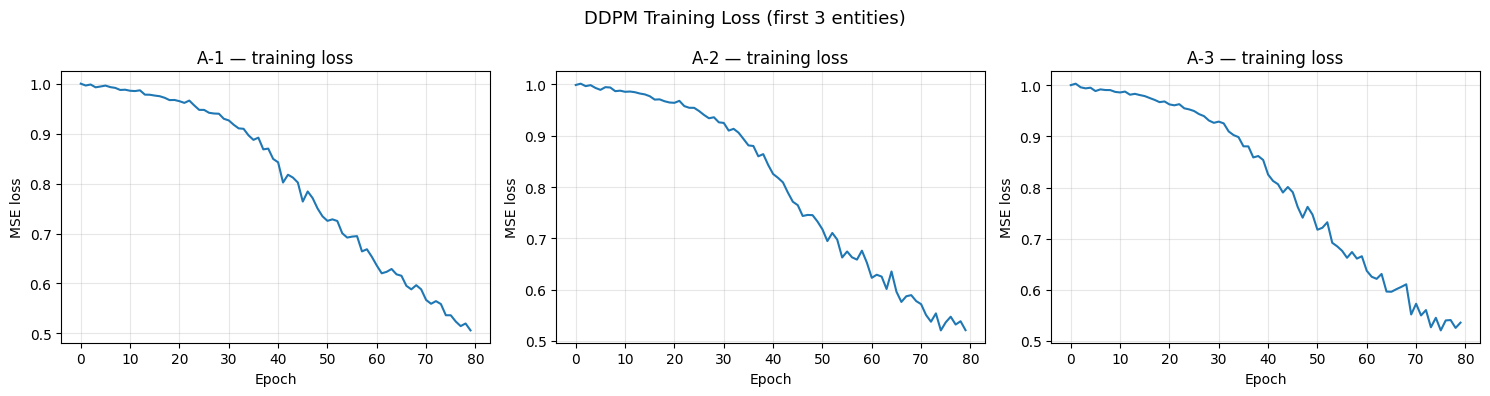

In [129]:
import csv as _csv
_lmap = {}
with open('labeled_anomalies.csv') as _f:
    for _row in _csv.DictReader(_f):
        _lmap[_row['chan_id']] = _row['spacecraft']

with open(RESULTS_DIR / "best_params_smap.json") as f:
    best_params_smap = json.load(f)
with open(RESULTS_DIR / "best_params_msl.json") as f:
    best_params_msl = json.load(f)

print("SMAP params:", best_params_smap)
print("MSL  params:", best_params_msl)

beta_start = 1e-4
beta_end   = 0.02
entity_losses = {}

for eid in tqdm(entities, desc="Training entities"):
    nc        = n_channels[eid]
    input_dim = window_size * nc

    bp = best_params_msl if _lmap.get(eid) == 'MSL' else best_params_smap

    train_w = np.load(DATA_DIR / f"{eid}_train.npy").reshape(-1, input_dim).astype(np.float32)

    sched = DiffusionScheduler(T=T, beta_start=beta_start, beta_end=beta_end)
    model = ConvDenoiser(n_channels=nc, window_size=window_size, hidden_dim=bp["hidden_dim"], T=T)

    model, losses = train_diffusion(model, sched, train_w, n_epochs=N_EPOCHS, lr=bp["lr"],
                                     batch_size=BATCH_SIZE, device=DEVICE)
    entity_losses[eid] = losses

    torch.save({
        "model":       model.state_dict(),
        "T":           T,
        "beta_start":  beta_start,
        "beta_end":    beta_end,
        "hidden_dim":  bp["hidden_dim"],
        "input_dim":   input_dim,
        "n_channels":  nc,
        "window_size": window_size,
        "t_eval":      bp["t_eval"],
    }, RESULTS_DIR / f"{eid}_model.pt")

print("All entities trained and saved.")

fig, axes = plt.subplots(1, min(3, len(entities)), figsize=(15, 4))
for ax, eid in zip(axes, entities[:3]):
    ax.plot(entity_losses[eid])
    ax.set_title(f"{eid} — training loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.grid(True, alpha=0.3)
plt.suptitle("DDPM Training Loss (first 3 entities)", fontsize=13)
plt.tight_layout()
plt.show()


## Anomaly Score Computation

For each entity we:
1. Load the saved checkpoint and rebuild the model.
2. Compute per-window anomaly scores on the **test** set (MSE after partial denoising at `T_EVAL`).
3. Also compute scores on the **validation** set (used later for threshold calibration).
4. Save both score arrays.

In [130]:
for eid in tqdm(entities, desc="Scoring entities"):
    nc        = n_channels[eid]
    input_dim = window_size * nc

    ckpt  = torch.load(RESULTS_DIR / f"{eid}_model.pt", map_location=DEVICE)
    sched = DiffusionScheduler(T=ckpt["T"], beta_start=ckpt["beta_start"], beta_end=ckpt["beta_end"])
    model = ConvDenoiser(
        n_channels=ckpt["n_channels"],
        window_size=ckpt["window_size"],
        hidden_dim=ckpt["hidden_dim"],
        T=ckpt["T"],
    )
    model.load_state_dict(ckpt["model"])
    model.to(DEVICE)
    model.eval()
    t_eval_eid = ckpt.get("t_eval", T_EVAL)

    test_w = np.load(DATA_DIR / f"{eid}_test.npy").reshape(-1, input_dim).astype(np.float32)
    test_scores = compute_diffusion_scores(model, sched, test_w, t_eval=t_eval_eid,
                                           batch_size=BATCH_SIZE, device=DEVICE)
    np.save(RESULTS_DIR / f"{eid}_test_scores.npy", test_scores)

    val_raw = np.load(DATA_DIR / f"{eid}_val.npy")
    if val_raw.ndim < 3 or len(val_raw) == 0:
        np.save(RESULTS_DIR / f"{eid}_val_scores.npy", np.array([], dtype=np.float32))
        continue
    val_w = val_raw.reshape(-1, input_dim).astype(np.float32)
    val_scores = compute_diffusion_scores(model, sched, val_w, t_eval=t_eval_eid,
                                          batch_size=BATCH_SIZE, device=DEVICE)
    np.save(RESULTS_DIR / f"{eid}_val_scores.npy", val_scores)

print("All scores saved to", RESULTS_DIR)

Scoring entities:   0%|          | 0/82 [00:00<?, ?it/s]

All scores saved to results/diffusion


## Score Distribution (Sample Entity)

Visualise the anomaly scores on the first entity: the top panel shows channel 0 of the raw test signal, the bottom panel shows the diffusion reconstruction scores with a 95th-percentile threshold and red shading over labelled anomaly regions.

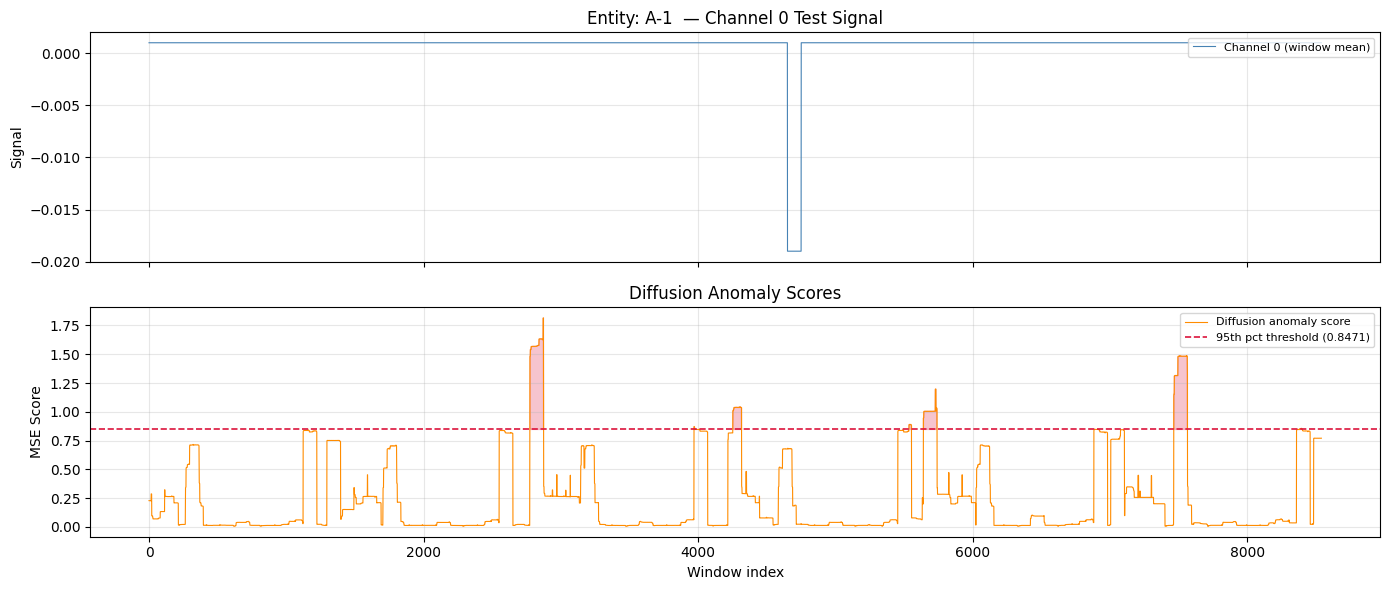

Threshold (95th pct): 0.847074
Windows above threshold: 427 / 8541


In [131]:
import pandas as pd

sample_eid = entities[0]
nc         = n_channels[sample_eid]
input_dim  = window_size * nc

# Raw test signal: (n_windows, 100, nc) → take channel 0, flatten time axis
test_raw    = np.load(DATA_DIR / f"{sample_eid}_test.npy")    # (N, 100, nc)
test_scores = np.load(RESULTS_DIR / f"{sample_eid}_test_scores.npy")  # (N,)

# For plotting, represent each window by its central timestep
n_windows = test_raw.shape[0]
time_axis = np.arange(n_windows)
channel0  = test_raw[:, :, 0].mean(axis=1)   # mean over window for display

# Threshold: 95th percentile of test scores
threshold = np.percentile(test_scores, 95)

# ── Load labelled anomalies ──────────────────────────────────────────────────
anom_segs = []
anom_csv  = Path("data/labeled_anomalies.csv")
if anom_csv.exists():
    df_anom = pd.read_csv(anom_csv)
    df_eid  = df_anom[df_anom["chan_id"] == sample_eid] if "chan_id" in df_anom.columns else pd.DataFrame()
    for _, row in df_eid.iterrows():
        try:
            segs = json.loads(row["anomaly_sequences"].replace("'", '"'))
            anom_segs.extend(segs)
        except Exception:
            pass

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: raw signal
ax1.plot(time_axis, channel0, color="steelblue", lw=0.8, label="Channel 0 (window mean)")
ax1.set_ylabel("Signal")
ax1.set_title(f"Entity: {sample_eid}  — Channel 0 Test Signal")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.3)

# Bottom: anomaly scores
ax2.plot(time_axis, test_scores, color="darkorange", lw=0.8, label="Diffusion anomaly score")
ax2.axhline(threshold, color="crimson", lw=1.2, ls="--", label=f"95th pct threshold ({threshold:.4f})")
ax2.fill_between(time_axis, test_scores, threshold,
                 where=(test_scores > threshold), color="crimson", alpha=0.25)
ax2.set_ylabel("MSE Score")
ax2.set_xlabel("Window index")
ax2.set_title("Diffusion Anomaly Scores")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.3)

# Shade labelled anomaly regions (in window-index space, assuming stride=1)
for ax in (ax1, ax2):
    for seg in anom_segs:
        if len(seg) == 2:
            ax.axvspan(seg[0], seg[1], color="red", alpha=0.15, zorder=0)

if anom_segs:
    red_patch = mpatches.Patch(color="red", alpha=0.3, label="Labelled anomaly")
    ax2.legend(
        handles=ax2.get_legend_handles_labels()[0] + [red_patch],
        labels=ax2.get_legend_handles_labels()[1] + ["Labelled anomaly"],
        loc="upper right", fontsize=8,
    )

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{sample_eid}_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Threshold (95th pct): {threshold:.6f}")
print(f"Windows above threshold: {(test_scores > threshold).sum()} / {len(test_scores)}")